# Grounding dataset pipeline - raw traces to hallucination-labeled dataset

**Author:** kj

Takes the raw client production traces and pushes them through the full grounding pipeline
until a hallucination-labeled dataset is produced, entirely on the local RTX PRO 6000 96GB
with open-weight judges - zero external API tokens. The evidence per trace is the production
agent's own retrieved+summarized bundle (up to ~184k tokens), so it is SAT-segmented, windowed
with overlap, and semantically retrieved down to the spans relevant to each claim before any
judge sees it - never truncated, never fed whole. Implements
`docs/auxiliary/evidence-chunked-judge-pipeline-recipe.md`.

## Approach

1. **Load** raw `raw_v5` traces + `golden_v5` gold labels - and see why the old whole-doc feed truncated a third of the corpus (visual)
2. **Segment** each evidence bundle into multilingual sentences with the OV int8 SaT model - clean boundaries across 10 languages
3. **Window** the sentences into overlapping passages small enough to embed, offsets preserved
4. **Retrieve** the top-k windows per claim with the OV int8 semantic cascade (bge-m3 -> reranker -> NLI) - so the judge sees only relevant evidence
5. **Anchor** each claim with a deterministic numeric/entity check - the fabricated part-numbers and thresholds that semantic similarity rubber-stamps
6. **Gate** on retrieval recall over gold-supported claims - if the support does not survive retrieval, the retriever is the ceiling and we stop here (visual)
7. **Judge** each claim against its assembled context with one open judge per run (bake-off across candidates), resumable per-model caches
8. **Evaluate** every judge and combo vs gold - per-judge confusion, hallucination F1, per-language kappa (visuals) - and pick the winning combo
9. **Save** the dual-agreed non-trivial verdicts as the final labeled dataset

## Output

- `data/interim/pipeline/` - windows + retrieval caches (resumable)
- `data/processed/dataset_pipeline/verdicts_<candidate>.parquet` - per-judge verdicts
- `data/processed/dataset_pipeline/records_open.parquet` - final hallucination-labeled dataset
- `data/processed/dataset_pipeline/REPORT.md` - aggregate metrics (no client text)


## How judgement and dataset preparation work

The pipeline turns raw production traces into a hallucination-labeled dataset by having
open-weight models judge each claim against the evidence the production agent actually used,
combining those judges as an ensemble, and validating the result against a Claude-labeled gold
set - all on the local GPU, no external tokens.

### The problem

A production trace is a question, the agent's answer, and the evidence bundle the agent retrieved
to write it. Each answer decomposes into claims; a claim is a hallucination when the evidence does
not support it. The goal is to label thousands of claims for hallucination without spending Claude
tokens, and to prove the open labels are trustworthy by measuring them against the existing Claude
gold.

### Evidence - chunk and retrieve, never truncate

The evidence bundle is the agent's own retrieved-and-summarized documentation, up to ~184k tokens.
Feeding it whole is impossible (it exceeds any judge's context) and wasteful (attention is O(n²) in
length). So each bundle is SAT-segmented into multilingual sentences, packed into overlapping
windows, and the top-k windows relevant to each claim are retrieved with the semantic cascade
(bge-m3 embedding → reranker → NLI). The judge sees only the evidence that matters, bounded to fit
its context. A retrieval-recall gate first checks that the retrieved windows still carry the support
for gold-supported claims - if retrieval drops the evidence, the retriever is the ceiling, not the
judge, and the run stops there.

### Judgement - an ensemble of open judges

Each judge (Gemma-27B, Llama-70B, Qwen-72B, gpt-oss-120b) is a base classifier: given a claim and
its retrieved evidence it returns SUPPORTED, UNSUPPORTED, or NOT_A_CLAIM. This is classic ensemble
classification. No single judge is trusted alone - each has blind spots (a reasoning model can
rationalize a claim into SUPPORTED; a model can be weak in one language). The ensemble combines them
so uncorrelated errors cancel. The combiner keeps the claims where judges agree - those are the
high-confidence labels - and resolves disagreements by a tiebreaker or a majority vote. Whether a
third judge is needed is itself an ensemble-design decision, made from the measured inter-judge
agreement and error-diversity rather than assumed.

```text
raw trace ─► claims
evidence  ─► SAT segment ─► overlapping windows ─► retrieve top-k per claim ─► [gate]
                                                                     │
                    claim + retrieved windows ──► judge₁ ┐
                                              ──► judge₂ ┤─► combine (agree / vote) ─► label
                                              ──► judge₃ ┘
```

### Trustworthiness - validate before trusting

Every judge is scored per-claim against the Claude gold: hallucination recall, precision, F1,
Cohen's κ, and a per-language breakdown so the aggregate never hides a per-language collapse.
Disagreements are inspected directly - where two judges split, which one tracks the gold - because
that is what separates a real signal from a coin flip and decides the combiner. Only a combined
verdict that clears the trustworthiness bar becomes a label.

### Dataset preparation

The validated, agreed verdicts on the gold traces form the re-labeled dataset; the same pipeline
extends to the unlabeled traces (claims extracted from the answer with SAT) to grow the corpus.
The output is `records_open.parquet` - claim, label, language, trace id, origin - plus an aggregate
report, with no client text in any tracked artifact.


## GPU selection

Pins the 96GB RTX PRO 6000 (sm_120) by **UUID** so the run is reproducible regardless of
CUDA enumeration order, and sets the vLLM/WSL2 environment before any GPU library is imported.
The 24GB PRO 4000 would OOM a 70B judge, so the pin is not optional.

In [1]:
import os
import sysconfig

# Pin the 96GB RTX PRO 6000 Blackwell by UUID (reproducible; ignores enumeration order).
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = os.environ.get("LLM_JUDGE_GPU", "GPU-a44e514a-aa5b-2844-35f1-4be28e1921e5")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# vLLM on sm_120 / WSL2
os.environ.setdefault("VLLM_ATTENTION_BACKEND", "FLASHINFER")   # Blackwell attention / FP8-KV path
os.environ.setdefault("VLLM_WSL2_ENABLE_PIN_MEMORY", "1")       # NVFP4 / MoE UVA
os.environ.setdefault("VLLM_ENABLE_V1_MULTIPROCESSING", "0")    # in-process engine, deterministic VRAM teardown
os.environ.setdefault("VLLM_NVFP4_GEMM_BACKEND", "cutlass")     # native FP4 GEMM (gpt-oss MXFP4)
os.environ.setdefault("VLLM_USE_DEEP_GEMM", "0")               # MoE: DeepGEMM SF bug on sm_120
os.environ.setdefault("VLLM_MOE_USE_DEEP_GEMM", "0")
os.environ.setdefault("HF_HUB_OFFLINE", "0")

# point FlashInfer's runtime JIT (sm_120 sampling/attention kernels) at the pip cu13 toolkit - nvcc is not on PATH
_cu13 = os.path.join(sysconfig.get_paths()["purelib"], "nvidia", "cu13")
os.environ.setdefault("CUDA_HOME", _cu13)
os.environ.setdefault("CUDA_PATH", _cu13)
os.environ["PATH"] = f"{_cu13}/bin:" + os.environ.get("PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{_cu13}/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
os.environ.setdefault("NVCC_APPEND_FLAGS", "-DCCCL_DISABLE_CTK_COMPATIBILITY_CHECK")
os.environ.setdefault("CUDA_CACHE_MAXSIZE", "4294967296")      # 4GB - persist the sm_120 kernel JIT across runs

'4294967296'

## Imports

All imports in one cell, grouped. `vllm` is imported lazily-guarded so the CPU stages
(segment -> retrieve -> gate) run even when the GPU / judge weights are not present yet.

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
import json
import gc
import re
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, cohen_kappa_score

# Rich output + progress
from rich import print as rprint
from rich.table import Table
from rich.progress import (
    Progress, SpinnerColumn, TextColumn, BarColumn,
    MofNCompleteColumn, TimeElapsedColumn, TimeRemainingColumn,
)

# GPU retrieval models (data-prep only; the shipped library serves the CPU OV cascade)
import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

# groundrails pipeline components
from groundrails.sat import SaTSegmenter
from groundrails.chunking import recursive_chunk
from groundrails import entity_check
from groundrails.extract import extract_claims

# vLLM judge (guarded - CPU stages must run without it)
try:
    from vllm import LLM, SamplingParams
    _VLLM = True
except Exception as _e:  # noqa: BLE001
    LLM = SamplingParams = None
    _VLLM = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reproducibility

Fixes the seed so window packing, retrieval tie-breaks, and any sampling are deterministic
across re-runs. Judges run greedy (temperature 0) so verdicts are reproducible too.

In [3]:
SEED = 0
import random
random.seed(SEED)
np.random.seed(SEED)

## Configuration

Every pipeline knob in one place. Window size and overlap set the retrieval granularity;
`TOP_K_WINDOWS` and `CTX_CAP_TOKENS` bound the judge context so it is never truncated.
`JUDGE_CANDIDATE` selects which open judge this run scores - one model per process keeps
VRAM clean, and per-model caches make the bake-off resumable.

In [4]:
# Paths
DATA = Path("../../data")
RAW_PATH  = DATA / "raw/raw_v5/raw_v5.parquet"
GOLD_PATH = DATA / "processed/golden_v5/golden_v5.parquet"
INTERIM   = DATA / "interim/pipeline"
OUT       = DATA / "processed" / os.environ.get("LLM_JUDGE_OUT", "dataset_pipeline")  # override for validation runs
INTERIM.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Sampling
SAMPLE_TRACES = int(os.environ.get("LLM_JUDGE_SAMPLE", "0")) or None   # 0 = full corpus

# Stage 2 - windowing
WINDOW_MAX_CHARS = 1500      # ~400 tokens/window (recursive_chunk default)
OVERLAP_RATIO    = 0.25      # trailing context carried into the next window

# Stage 3 - retrieval
TOP_K_WINDOWS = 5            # windows kept per claim
RR_THR        = 0.30         # reranker relevance threshold (primary retrieval-surfaced signal)
ENT_THR       = 0.50         # NLI entailment threshold (secondary signal)
RECALL_GATE   = 0.95         # min retrieval recall on gold-supported claims to proceed

# Stage 5 - assembly / judging
CTX_CAP_TOKENS = 8000        # cap on the assembled judge context (~30k chars)
CHUNK          = 5           # claims judged per LLM call; small so a reasoning judge's <think> over
                             # the chunk stays short - 15 overflowed even gpt-oss at 3072 max_tokens
CHARS_PER_TOK  = 3.7         # empirical mean for this English+markdown corpus (evidence sizing)

# Stage 6 - judge candidate (one per run; env-selected)
JUDGES = {
    "gemma":       {"id": "RedHatAI/gemma-3-27b-it-FP8-dynamic",          "quant": None, "reason": False, "max_tokens": 512,  "max_num_seqs": 48},
    "llama70":     {"id": "RedHatAI/Llama-3.3-70B-Instruct-FP8-dynamic",  "quant": None, "reason": False, "max_tokens": 1024, "max_num_seqs": 24},
    "qwen72":      {"id": "RedHatAI/Qwen2.5-72B-Instruct-FP8-dynamic",    "quant": None, "reason": False, "max_tokens": 1024, "max_num_seqs": 24},
    "gptoss-low":  {"id": "openai/gpt-oss-120b",                          "quant": None, "reason": True,  "max_tokens": 4096, "max_num_seqs": 32, "effort": "low"},
    "gptoss-medium": {"id": "openai/gpt-oss-120b",                        "quant": None, "reason": True,  "max_tokens": 6144, "max_num_seqs": 32, "effort": "medium"},
    "gptoss-high": {"id": "openai/gpt-oss-120b",                          "quant": None, "reason": True,  "max_tokens": 8192, "max_num_seqs": 32, "effort": "high"},
}
JUDGE_CANDIDATE = os.environ.get("JUDGE_CANDIDATE", "gemma")
MAX_MODEL_LEN   = int(os.environ.get("LLM_JUDGE_MAX_LEN", "20480"))   # room for evidence + a long reasoning tail (no truncation)
GPU_MEM_UTIL    = 0.92
PHASE2          = os.environ.get("LLM_JUDGE_PHASE2", "0") == "1"   # extend labels to unlabeled traces
RUN_JUDGE       = os.environ.get("RUN_JUDGE", "1") == "1"          # 0 = run CPU stages + gate only, skip the judge

spec = JUDGES[JUDGE_CANDIDATE]

rprint(f"""[bold medium_purple]Grounding dataset pipeline[/bold medium_purple]
[dim]{"─" * 46}[/dim]
[bold slate_blue1]Data[/bold slate_blue1]
  Raw traces: [dim]{RAW_PATH}[/dim]
  Gold:       [dim]{GOLD_PATH}[/dim]
  Sample:     [dark_sea_green]{SAMPLE_TRACES or "full corpus"}[/dark_sea_green]

[bold slate_blue1]Chunk & retrieve[/bold slate_blue1]
  Window max chars: [dark_sea_green]{WINDOW_MAX_CHARS}[/dark_sea_green] [dim](overlap {OVERLAP_RATIO})[/dim]
  Top-k windows:    [dark_sea_green]{TOP_K_WINDOWS}[/dark_sea_green]
  Recall gate:      [dark_sea_green]{RECALL_GATE}[/dark_sea_green] [dim](NLI ent >= {ENT_THR})[/dim]

[bold slate_blue1]Judge[/bold slate_blue1]
  Candidate:   [cadet_blue]{JUDGE_CANDIDATE}[/cadet_blue] -> [cadet_blue]{spec['id']}[/cadet_blue]
  Context cap: [dark_sea_green]{CTX_CAP_TOKENS}[/dark_sea_green] tok [dim](max_model_len {MAX_MODEL_LEN})[/dim]
  Reasoning:   [grey70]{spec.get('effort') if spec['reason'] else 'off'}[/grey70]
  Phase 2 ext: [grey70]{PHASE2}[/grey70]

[bold slate_blue1]Device[/bold slate_blue1]
  GPU: [cyan]{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}[/cyan]
  CUDA_VISIBLE_DEVICES: [green]{os.environ['CUDA_VISIBLE_DEVICES'][:24]}...[/green]
  vLLM available: [{'green' if _VLLM else 'indian_red'}]{_VLLM}[/]
""")

Grounding dataset pipeline
──────────────────────────────────────────────
Data
  Raw traces: ../../data/raw/raw_v5/raw_v5.parquet
  Gold:       ../../data/processed/golden_v5/golden_v5.parquet
  Sample:     full corpus

Chunk & retrieve
  Window max chars: 1500 (overlap 0.25)
  Top-k windows:    5
  Recall gate:      0.95 (NLI ent >= 0.5)

Judge
  Candidate:   gptoss-medium -> openai/gpt-oss-120b
  Context cap: 8000 tok (max_model_len 20480)
  Reasoning:   medium
  Phase 2 ext: False

Device
  GPU: NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
  CUDA_VISIBLE_DEVICES: GPU-a44e514a-aa5b-2844-3...
  vLLM available: True

## Pipeline helpers

The reusable stage functions, each wrapping an existing `groundrails` component so the pipeline
is a wiring layer, not a reimplementation. Kept in one cell so the stages below read as a flow.

In [5]:
_BIN = {"SUPPORTED": 1, "UNSUPPORTED": 0}

def make_windows(seg, evidence: str) -> list[str]:
    """Stage 1+2: SaT-segment then pack sentences into overlapping windows."""
    sents = seg.split(evidence)
    packed = "\n\n".join(s.strip() for s in sents if s.strip())
    return [c.text for c in recursive_chunk(packed, max_chars=WINDOW_MAX_CHARS, overlap_ratio=OVERLAP_RATIO)]

def anchor_flags(claim: str, evidence: str) -> dict:
    """Stage 4: deterministic numeric/entity mismatch check."""
    num = entity_check.find_numeric_mismatches(claim, evidence)
    absent = entity_check.find_absent_entities(claim, evidence)
    return {"num_mismatch": len(num), "absent_entity": len(absent)}

def assemble_context(topk_windows: list[str], budget_chars: int) -> str:
    """Stage 5: join retrieved windows up to a char budget (bounds the judge prompt)."""
    out, used = [], 0
    for w in topk_windows:
        if used + len(w) > budget_chars:
            break
        out.append(w); used += len(w) + 5
    return "\n---\n".join(out)

JUDGE_PROMPT = """You are a strict grounding judge for a technical support assistant.
Evidence below is the ONLY source of truth. For each numbered claim decide:

- SUPPORTED: the evidence explicitly supports the claim (translation across languages is fine)
- UNSUPPORTED: the claim asserts something the evidence does not contain or contradicts
- NOT_A_CLAIM: the sentence is not a checkable factual assertion (greeting, offer to help,
  question, navigation/connective text, pure formatting fragment)

Evidence:
<<<EVIDENCE
{evidence}
EVIDENCE>>>

There are exactly {n} claims, numbered 1 to {n}. Judge ONLY these numbered claims.

Claims:
{claims}

Reply with ONLY a JSON array with exactly {n} objects, idx 1 to {n}, no prose:
[{{"idx": 1, "label": "SUPPORTED"}}, ...]"""

def _strip_think(txt: str) -> str:
    i = txt.rfind("</think>")
    return txt[i + len("</think>"):] if i != -1 else txt

def parse_labels(txt: str, n: int, reason: bool) -> dict:
    """Robust: normalize byte-BPE detok markers, strip <think>, then extract every flat {...}
    verdict object by regex. Tolerates a bare object (1-item chunks drop the array wrapper),
    trailing prose after the array (a stray ']' broke the old first-'['..last-']' slice),
    newline-joined objects, markdown fences, and key order - the failure modes that sank the
    512/1024 bake-off were parse fragility, not token truncation (except gpt-oss reasoning)."""
    txt = txt.replace("Ġ", " ").replace("Ċ", "\n").replace("ĉ", "\t")
    if reason:
        # gpt-oss harmony emits an analysis channel then a final channel - parse only the final answer;
        # fall back to <think> stripping for other reasoning models.
        if "final<|message|>" in txt:
            txt = txt.split("final<|message|>")[-1]
        else:
            txt = _strip_think(txt)
    out = {}
    for m in re.finditer(r"\{[^{}]*\}", txt):
        try:
            o = json.loads(m.group(0))
            idx = int(o["idx"]); lab = str(o["label"]).upper()
            if 1 <= idx <= n and lab in {"SUPPORTED", "UNSUPPORTED", "NOT_A_CLAIM"}:
                out[idx - 1] = lab
        except Exception:  # noqa: BLE001
            continue
    return out

PALETTE = {"primary": "#3498DB", "secondary": "#E74C3C", "tertiary": "#2ECC71", "grey": "#95A5A6"}
rprint("[dark_sea_green]✓[/dark_sea_green] pipeline helpers defined")

✓ pipeline helpers defined

## GPU retrieval models

The reranker and NLI are cross-encoders - the retrieval bottleneck. On the shipped CPU OV cascade
they take ~an hour over the corpus; batched on the 96GB card they take minutes (batching is the 30x
lever). Loads bge-m3 (embed), bge-reranker-v2-m3 (relevance), mDeBERTa-v3-NLI (entailment) on GPU in
bf16, per the my-gpu encoder/entailer recipe. This is a prep-time accelerator - the deployed library
still serves the deterministic CPU cascade.

In [6]:
# transformers' "Loading weights" tqdm bar recurses through rich's stdout proxy inside a Progress
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TORCHINDUCTOR_MAX_AUTOTUNE", "0")   # autotune floods rich stdout + OOMs some sm_120 configs
from transformers.utils import logging as _hf_logging
_hf_logging.disable_progress_bar()
_hf_logging.set_verbosity_error()

# torch.compile(dynamic=True): correct 1.26x on DeBERTa disentangled attention (sdpa is unavailable there,
# and FlashDeBERTa returns wrong verdicts on sm_120); bf16+sdpa carries the XLM-R encoders
COMPILE = os.environ.get("RETRIEVAL_COMPILE", "1") == "1"
DEV = "cuda" if torch.cuda.is_available() else "cpu"
EMB_ID, RR_ID, NLI_ID = "BAAI/bge-m3", "BAAI/bge-reranker-v2-m3", "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
_G = {}

def _mdl(cls, mid):
    # my-gpu encoder/entailer recipe: bf16 + sdpa (free 1.16-1.34x); eager fallback where unsupported (DeBERTa)
    try:
        m = cls.from_pretrained(mid, torch_dtype=torch.bfloat16, attn_implementation="sdpa").to(DEV).eval()
    except (ValueError, ImportError, KeyError):
        m = cls.from_pretrained(mid, torch_dtype=torch.bfloat16).to(DEV).eval()
    if COMPILE:
        try:
            m = torch.compile(m, dynamic=True)   # graph fusion; one compile, no per-shape recompile
        except Exception:  # noqa: BLE001
            pass
    return m

def _load_gpu_models():
    if _G:
        return
    _G["et"] = AutoTokenizer.from_pretrained(EMB_ID); _G["e"] = _mdl(AutoModel, EMB_ID)
    _G["rt"] = AutoTokenizer.from_pretrained(RR_ID);  _G["r"] = _mdl(AutoModelForSequenceClassification, RR_ID)
    _G["nt"] = AutoTokenizer.from_pretrained(NLI_ID); _G["n"] = _mdl(AutoModelForSequenceClassification, NLI_ID)
    _G["ent"] = next(i for i, l in _G["n"].config.id2label.items() if "entail" in l.lower())
    rprint(f"[dark_sea_green]✓[/dark_sea_green] GPU retrieval models on [green]{torch.cuda.get_device_name(0)}[/green] [dim](bf16 + sdpa)[/dim]")

@torch.no_grad()
def gpu_embed(texts, bs=64):
    """bge-m3 dense embeddings - CLS pooling, L2-normalized."""
    _load_gpu_models(); out = []
    for i in range(0, len(texts), bs):
        enc = _G["et"](texts[i:i+bs], padding=True, truncation=True, max_length=512, return_tensors="pt").to(DEV)
        h = _G["e"](**enc).last_hidden_state[:, 0]
        out.append(torch.nn.functional.normalize(h.float(), dim=-1).cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0, 1024), dtype=np.float32)

@torch.no_grad()
def gpu_rerank(pairs, bs=64):
    """bge-reranker-v2-m3 relevance in [0,1] for (query, passage) pairs."""
    _load_gpu_models(); out = []
    for i in range(0, len(pairs), bs):
        b = pairs[i:i+bs]
        enc = _G["rt"]([q for q, _ in b], [p for _, p in b], padding=True, truncation=True,
                       max_length=512, return_tensors="pt").to(DEV)
        out.append(torch.sigmoid(_G["r"](**enc).logits.squeeze(-1).float()).cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0,), dtype=np.float32)

@torch.no_grad()
def gpu_nli(pairs, bs=64):
    """mDeBERTa entailment probability for (premise, hypothesis) pairs."""
    _load_gpu_models(); out = []
    for i in range(0, len(pairs), bs):
        b = pairs[i:i+bs]
        enc = _G["nt"]([p for p, _ in b], [h for _, h in b], padding=True, truncation=True,
                       max_length=512, return_tensors="pt").to(DEV)
        out.append(torch.softmax(_G["n"](**enc).logits.float(), dim=-1)[:, _G["ent"]].cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0,), dtype=np.float32)

rprint("[dark_sea_green]✓[/dark_sea_green] GPU retrieval helpers defined [dim](lazy-loaded on first use)[/dim]")

✓ GPU retrieval helpers defined (lazy-loaded on first use)

## Data loading

Loads the raw client traces and the gold labels, and builds the per-trace judging *units*
(one evidence bundle + its claims). The gold `role=="eval"` rows carry human-verified labels
(1 supported / 0 hallucination) for validation; unlabeled traces feed the Phase-2 extension.
The visual shows why the old whole-document feed failed - a third of traces exceed any single
judge context.

In [7]:
raw = pd.read_parquet(RAW_PATH)
gold = pd.read_parquet(GOLD_PATH)
ev = gold[gold["role"] == "eval"].copy()

units = []   # {trace_id, evidence, claims[], gold[], lang[]}
for tid, g in ev.groupby("trace_id"):
    g = g.reset_index(drop=True); tid = str(tid)
    units.append({
        "trace_id": tid,
        "evidence": str(g["source_text"].iloc[0]),
        "claims":   g["claim"].astype(str).tolist(),
        "gold":     g["label"].astype(int).tolist(),
        "lang":     g["lang_norm"].astype(str).tolist(),
    })
if SAMPLE_TRACES:
    units = units[:SAMPLE_TRACES]

n_claims = sum(len(u["claims"]) for u in units)
ev_toks = np.array([len(u["evidence"]) / CHARS_PER_TOK for u in units])
rprint(f"[bold slate_blue1]Loaded[/bold slate_blue1] [dark_sea_green]{len(units)}[/dark_sea_green] traces, "
       f"[dark_sea_green]{n_claims}[/dark_sea_green] gold claims, "
       f"[dark_sea_green]{len(set(l for u in units for l in u['lang']))}[/dark_sea_green] languages")

Loaded 636 traces, 5857 gold claims, 24 languages

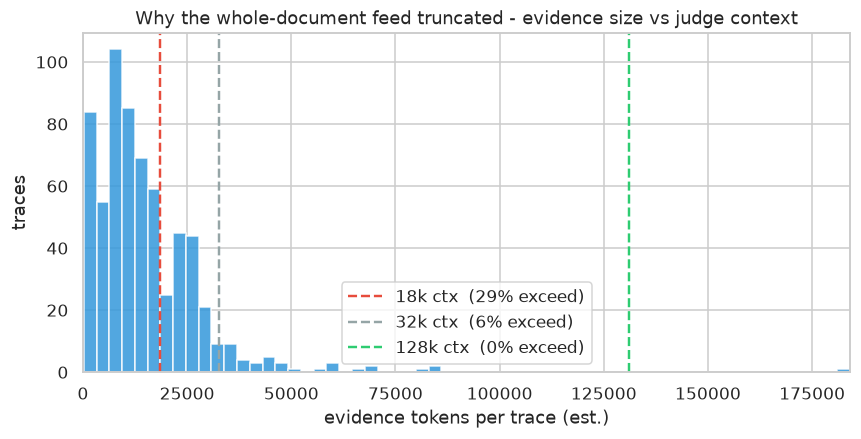

In [8]:
# Visual: evidence-size distribution vs candidate judge contexts
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ev_toks, bins=60, color=PALETTE["primary"], alpha=0.85)
for ctx, c in [(18432, PALETTE["secondary"]), (32768, PALETTE["grey"]), (131072, PALETTE["tertiary"])]:
    frac = (ev_toks > ctx).mean() * 100
    ax.axvline(ctx, color=c, ls="--", lw=1.6, label=f"{ctx//1024}k ctx  ({frac:.0f}% exceed)")
ax.set_xlabel("evidence tokens per trace (est.)"); ax.set_ylabel("traces")
ax.set_title("Why the whole-document feed truncated - evidence size vs judge context")
ax.set_xlim(0, min(ev_toks.max(), 200000)); ax.legend()
plt.show()

## Stage 1-2: Segment and window

Segments every unique evidence bundle into multilingual sentences with the OV int8 SaT model,
then packs them into overlapping windows small enough to embed. Runs once per distinct bundle
(evidence is shared across a trace's claims) and caches to `data/interim/pipeline`, so re-runs
are instant. Progress tracked per bundle.

In [9]:
WIN_CACHE = INTERIM / "windows.json"
if WIN_CACHE.exists():
    windows_by_trace = json.loads(WIN_CACHE.read_text())
    rprint(f"[dark_sea_green]✓[/dark_sea_green] loaded cached windows for "
           f"[dark_sea_green]{len(windows_by_trace)}[/dark_sea_green] traces")
else:
    seg = SaTSegmenter()
    windows_by_trace = {}
    with Progress(SpinnerColumn(), TextColumn("[steel_blue]{task.description}"),
                  BarColumn(bar_width=38), MofNCompleteColumn(), TimeElapsedColumn(),
                  TimeRemainingColumn(), refresh_per_second=8) as prog:
        t = prog.add_task("SaT segment + window", total=len(units))
        for u in units:
            windows_by_trace[u["trace_id"]] = make_windows(seg, u["evidence"])
            prog.advance(t)
        prog.update(t, completed=len(units)); prog.refresh()
    WIN_CACHE.write_text(json.dumps(windows_by_trace))
    rprint(f"[dark_sea_green]✓[/dark_sea_green] windowed [dark_sea_green]{len(windows_by_trace)}[/dark_sea_green] bundles -> cached")

wc = np.array([len(v) for v in windows_by_trace.values()])
rprint(f"windows/trace: median [dark_sea_green]{int(np.median(wc))}[/dark_sea_green]  "
       f"max [dark_sea_green]{int(wc.max())}[/dark_sea_green]")

✓ loaded cached windows for 636 traces

windows/trace: median 33  max 493

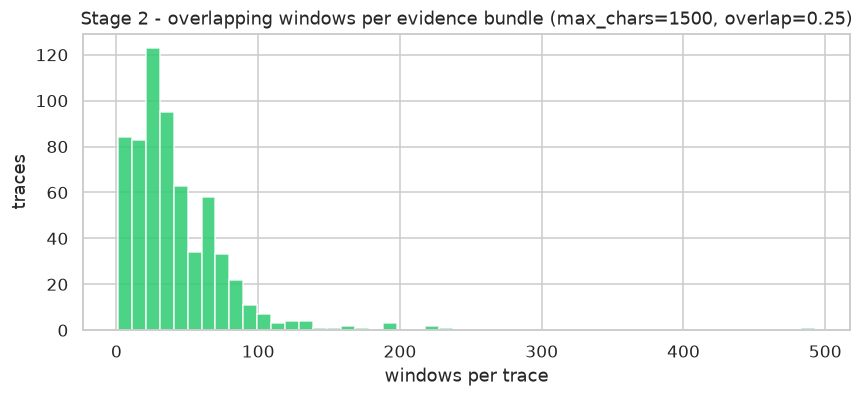

In [10]:
# Visual: window count per trace
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(wc, bins=50, color=PALETTE["tertiary"], alpha=0.85)
ax.set_xlabel("windows per trace"); ax.set_ylabel("traces")
ax.set_title(f"Stage 2 - overlapping windows per evidence bundle (max_chars={WINDOW_MAX_CHARS}, overlap={OVERLAP_RATIO})")
plt.show()

## Stage 3-4: Retrieve and anchor (GPU)

For each claim, embeds its trace's windows with bge-m3 and keeps the top-k by cosine, then batches
the reranker and NLI over every (claim, window) pair on the GPU for relevance and entailment. The
deterministic numeric/entity anchor check runs alongside for fabricated part-numbers and thresholds.
Narrows a 184k-token bundle to a few relevant windows per claim; result cached.

In [11]:
RET_CACHE = INTERIM / "retrieval.json"
if RET_CACHE.exists():
    retrieval = json.loads(RET_CACHE.read_text())
    rprint(f"[dark_sea_green]✓[/dark_sea_green] loaded cached retrieval for [dark_sea_green]{len(retrieval)}[/dark_sea_green] claims")
else:
    from collections import defaultdict
    retrieval = {}
    pq, pp, pk = [], [], []   # (claim, window) pairs + retrieval key, for batched rerank/NLI
    _load_gpu_models()        # load outside the Progress context (loading bar recurses inside rich)
    # Phase A - embed windows + claims per trace, cosine top-k, anchors
    with Progress(SpinnerColumn(), TextColumn("[steel_blue]{task.description}"),
                  BarColumn(bar_width=38), MofNCompleteColumn(), TimeElapsedColumn(),
                  TimeRemainingColumn(), refresh_per_second=6) as prog:
        t = prog.add_task("embed + top-k (GPU)", total=len(units))
        for u in units:
            tid = u["trace_id"]; wins = windows_by_trace[tid]; claims = u["claims"]
            if not wins:
                for pos in range(len(claims)):
                    retrieval[f"{tid}::{pos}"] = {"win": [], "cos": 0.0, "rr": 0.0, "ent": 0.0, "num_mismatch": 0, "absent": 0}
                prog.advance(t); continue
            wemb = gpu_embed(wins); cemb = gpu_embed(claims)
            sims = cemb @ wemb.T                       # (claims, windows), both L2-normalized
            for pos, claim in enumerate(claims):
                idx = np.argsort(-sims[pos])[:TOP_K_WINDOWS]
                af = anchor_flags(claim, u["evidence"])
                key = f"{tid}::{pos}"
                retrieval[key] = {"win": [int(i) for i in idx], "cos": float(sims[pos][idx[0]]),
                                  "rr": 0.0, "ent": 0.0,
                                  "num_mismatch": af["num_mismatch"], "absent": af["absent_entity"]}
                for i in idx:
                    pq.append(claim); pp.append(wins[int(i)]); pk.append(key)
            prog.advance(t)
        prog.update(t, completed=len(units)); prog.refresh()
    # Phase B - batched reranker + NLI over all pairs, aggregate max per claim
    rprint(f"[steel_blue]scoring[/steel_blue] [dark_sea_green]{len(pq)}[/dark_sea_green] (claim, window) pairs on GPU (rerank + NLI)...")
    rr = gpu_rerank(list(zip(pq, pp)))
    ent = gpu_nli(list(zip(pp, pq)))                   # premise=window, hypothesis=claim
    rr_max, ent_max = defaultdict(float), defaultdict(float)
    for k, r, e in zip(pk, rr, ent):
        if r > rr_max[k]: rr_max[k] = float(r)
        if e > ent_max[k]: ent_max[k] = float(e)
    for k in retrieval:
        retrieval[k]["rr"] = rr_max.get(k, 0.0); retrieval[k]["ent"] = ent_max.get(k, 0.0)
    RET_CACHE.write_text(json.dumps(retrieval))
    rprint(f"[dark_sea_green]✓[/dark_sea_green] retrieved + anchored [dark_sea_green]{len(retrieval)}[/dark_sea_green] claims (GPU) -> cached")

✓ loaded cached retrieval for 5857 claims

## Retrieval-recall gate

The go/no-go before spending a judge-second. For every gold-**supported** claim, checks whether
the retrieved windows still carry the support - measured by reranker relevance (`rr_max`), with
cosine and NLI entailment as secondary signals. The diagnostic that matters is *separation*: if
gold-supported claims score higher than gold-hallucination claims on the retrieved windows, the
cascade surfaced the right evidence and the judge has something to work with. If retrieval drops
the supporting span, a supported claim would be judged a hallucination - the retriever, not the
judge, becomes the ceiling.

In [12]:
srows = []
for u in units:
    for pos, gl in enumerate(u["gold"]):
        r = retrieval.get(f"{u['trace_id']}::{pos}")
        if r is not None:
            srows.append({"gold": gl, "lang": u["lang"][pos],
                          "cos": r["cos"], "rr": r["rr"], "ent": r["ent"]})
sig_df = pd.DataFrame(srows)
sup = sig_df[sig_df["gold"] == 1]   # gold supported
hal = sig_df[sig_df["gold"] == 0]   # gold hallucination

# retrieval recall: gold-supported claims whose retrieved windows carry reranker relevance
recall = float((sup["rr"] >= RR_THR).mean()) if len(sup) else float("nan")
status = ("dark_sea_green", "✓ PASS") if recall >= RECALL_GATE else ("dark_goldenrod", "review threshold")

t = Table(title="Retrieval-recall gate - cascade signal separation (supported vs hallucination)")
for c in ("signal", "supported mean", "hallucination mean", "separation"):
    t.add_column(c)
for s in ("cos", "rr", "ent"):
    ms, mh = sup[s].mean(), hal[s].mean()
    t.add_row(s, f"{ms:.3f}", f"{mh:.3f}", f"[{'dark_sea_green' if ms>mh else 'indian_red'}]{ms - mh:+.3f}[/]")
rprint(t)
rprint(f"[bold slate_blue1]Retrieval recall[/bold slate_blue1] (rr_max >= {RR_THR}) on "
       f"[dark_sea_green]{len(sup)}[/dark_sea_green] gold-supported claims: "
       f"[{status[0]}]{recall:.3f}[/{status[0]}]  (gate {RECALL_GATE})  [{status[0]}]{status[1]}[/{status[0]}]")

Retrieval-recall gate - cascade signal separation (supported 
                      vs hallucination)                      
┏━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ signal ┃ supported mean ┃ hallucination mean ┃ separation ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ cos    │ 0.640          │ 0.580              │ +0.059     │
│ rr     │ 0.640          │ 0.214              │ +0.426     │
│ ent    │ 0.535          │ 0.188              │ +0.346     │
└────────┴────────────────┴────────────────────┴────────────┘

Retrieval recall (rr_max >= 0.3) on 3892 gold-supported claims: 0.748  (gate 0.95)  review threshold

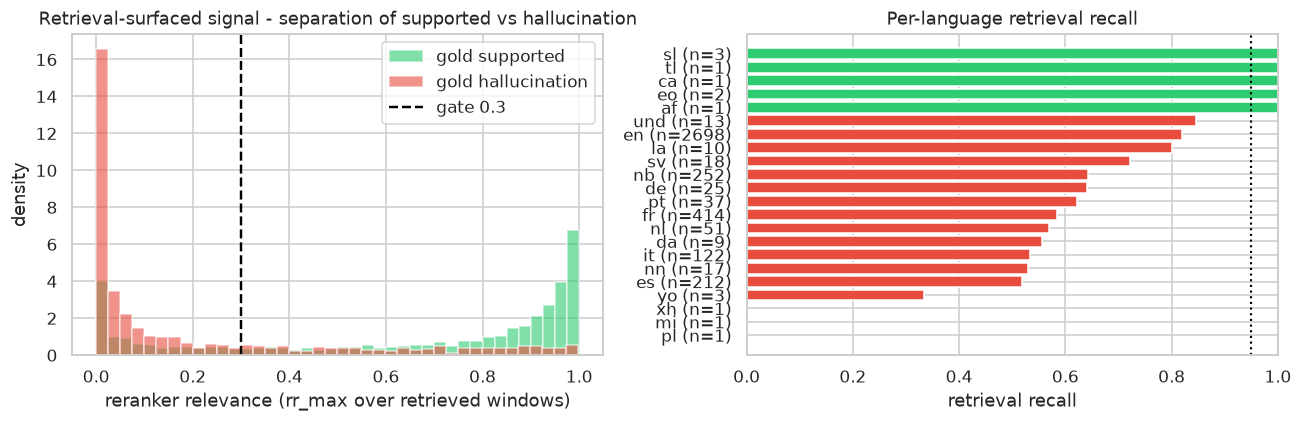

In [13]:
# Visual: signal separation (supported vs hallucination) + per-language retrieval recall
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(sup["rr"], bins=40, alpha=0.6, color=PALETTE["tertiary"], label="gold supported", density=True)
a1.hist(hal["rr"], bins=40, alpha=0.6, color=PALETTE["secondary"], label="gold hallucination", density=True)
a1.axvline(RR_THR, color="black", ls="--", lw=1.6, label=f"gate {RR_THR}")
a1.set_xlabel("reranker relevance (rr_max over retrieved windows)"); a1.set_ylabel("density")
a1.set_title("Retrieval-surfaced signal - separation of supported vs hallucination"); a1.legend()
by_lang = sup.groupby("lang")["rr"].apply(lambda s: (s >= RR_THR).mean()).sort_values()
colors = [PALETTE["secondary"] if v < RECALL_GATE else PALETTE["tertiary"] for v in by_lang.values]
a2.barh([f"{l} (n={(sup['lang']==l).sum()})" for l in by_lang.index], by_lang.values, color=colors)
a2.axvline(RECALL_GATE, color="black", ls=":", lw=1.4)
a2.set_xlabel("retrieval recall"); a2.set_title("Per-language retrieval recall"); a2.set_xlim(0, 1)
plt.tight_layout(); plt.show()

## Stage 5-6: Assemble and judge

Assembles each 25-claim chunk's judge context from the union of its claims' retrieved windows
(capped, never truncated), then judges with the selected open model. One candidate per run
(`JUDGE_CANDIDATE`), one model per process - vLLM v1 never frees VRAM in-process, so the
bake-off is driven by re-executing this notebook per candidate. Verdicts cache per model, so a
re-run resumes and the evaluation cells read every candidate present.

In [14]:
VERD_PATH = OUT / f"verdicts_{JUDGE_CANDIDATE}.parquet"

def build_prompts(units, retrieval, windows_by_trace):
    # Bound the whole prompt to MAX_MODEL_LEN: reserve output + scaffold, budget the rest in chars at
    # 2.5 chars/token - BELOW the observed densest 2.83 (number/markdown text), so token count can't overflow.
    TOK_CH = 2.5
    ev_tok_budget = MAX_MODEL_LEN - spec["max_tokens"] - 400
    prompts, meta = [], []   # meta: list of (tid, [positions]) per prompt
    for u in units:
        tid = u["trace_id"]; wins = windows_by_trace[tid]; claims = u["claims"]
        for off in range(0, len(claims), CHUNK):
            positions = list(range(off, min(off + CHUNK, len(claims))))
            numbered = "\n".join(f"{i+1}. {claims[p]}" for i, p in enumerate(positions))
            budget_chars = max(1000, int(ev_tok_budget * TOK_CH) - len(numbered))
            win_ids = []
            for pos in positions:
                win_ids += retrieval.get(f"{tid}::{pos}", {}).get("win", [])
            uniq = sorted(set(win_ids))
            ctx = assemble_context([wins[i] for i in uniq if i < len(wins)], budget_chars)
            prompts.append(JUDGE_PROMPT.format(evidence=ctx, n=len(positions), claims=numbered))
            meta.append((tid, positions))
    return prompts, meta

if VERD_PATH.exists():
    verdicts = pd.read_parquet(VERD_PATH)
    rprint(f"[dark_sea_green]✓[/dark_sea_green] loaded cached verdicts for [cadet_blue]{JUDGE_CANDIDATE}[/cadet_blue] "
           f"([dark_sea_green]{len(verdicts)}[/dark_sea_green] claims)")
elif not _VLLM or not RUN_JUDGE:
    why = "vLLM unavailable" if not _VLLM else "RUN_JUDGE=0 (CPU-only pass)"
    rprint(f"[dark_goldenrod]⚠[/dark_goldenrod] skipping judge stage - {why}. "
           "CPU stages + retrieval-recall gate above are complete.")
    verdicts = None
else:
    prompts, meta = build_prompts(units, retrieval, windows_by_trace)
    kw = dict(model=spec["id"], dtype="bfloat16", kv_cache_dtype="auto",
              max_model_len=MAX_MODEL_LEN, gpu_memory_utilization=GPU_MEM_UTIL,
              max_num_seqs=spec["max_num_seqs"], enforce_eager=False, seed=SEED)
    if spec["quant"]:
        kw["quantization"] = spec["quant"]
    llm = LLM(**kw)
    _tok = llm.get_tokenizer()
    # Reasoning judges run through the model's OWN chat template with an explicit reasoning_effort. Raw
    # completion prompts silently ignore effort - the flaw that made the old low/high "ensemble" inert
    # (both were really one config). validated: chat-template low kappa 0.833, low+high agreed 0.853 vs gold.
    if spec["reason"] and spec.get("effort"):
        ptexts = [_tok.apply_chat_template([{"role": "user", "content": p}], tokenize=False,
                                           add_generation_prompt=True, reasoning_effort=spec["effort"]) for p in prompts]
    else:
        ptexts = prompts
    # Length-bucketing: process similar-length prompts together so a batch's wall-clock is set by peers,
    # not by one long outlier; outputs are un-permuted back to prompt order.
    order = sorted(range(len(ptexts)), key=lambda i: len(ptexts[i]))

    import tqdm as _tqdmmod
    _lp = Path("../../logs"); _lp.mkdir(exist_ok=True)
    _pf = open(_lp / f"judge-{JUDGE_CANDIDATE}-progress.log", "a", buffering=1)
    class _TeeTqdm(_tqdmmod.tqdm):
        def __init__(self, *a, **k):
            k.setdefault("mininterval", 1.0); super().__init__(*a, **k)
        def display(self, *a, **k):
            r = super().display(*a, **k)
            try:
                _pf.write(f"judge[{JUDGE_CANDIDATE}] {self.n}/{self.total} ({(100*self.n)//max(self.total or 1,1)}%)\n"); _pf.flush()
            except Exception:
                pass
            return r

    # No-truncation guarantee: generate, then re-run any output that hit the token cap
    # (finish_reason == "length") with a DOUBLED budget, looping until none are capped. A truncated
    # verdict is a LOST label (survivorship bias toward easy claims), never a wrong one - so it is never
    # accepted. The final assert makes the guarantee un-regressable.
    texts = [None] * len(ptexts)
    todo = list(order); budget = spec["max_tokens"]; rnd = 0
    while todo:
        outs = llm.generate([ptexts[i] for i in todo], SamplingParams(temperature=0.0, max_tokens=budget), use_tqdm=_TeeTqdm)
        capped = []
        for i, o in zip(todo, outs):
            if o.outputs[0].finish_reason == "length":
                capped.append(i)
            else:
                texts[i] = o.outputs[0].text
        _pf.write(f"round {rnd} budget {budget}: {len(capped)}/{len(todo)} capped\n"); _pf.flush()
        if not capped:
            break
        nb_ = min(budget * 2, MAX_MODEL_LEN - 3000)
        if nb_ <= budget:                      # cannot grow further within context
            break
        todo = capped; budget = nb_; rnd += 1
    _pf.close()
    assert all(t is not None for t in texts), \
        f"no-truncation guarantee FAILED: {sum(t is None for t in texts)} prompts still capped at budget {budget}"

    rows = []; raws = []
    for j, raw in enumerate(texts):
        tid, positions = meta[j]
        raws.append({"trace_id": tid, "off": positions[0], "n": len(positions), "raw": raw})
        labs = parse_labels(raw, len(positions), spec["reason"])
        for i, pos in enumerate(positions):
            rows.append({"trace_id": tid, "pos": pos, "label": labs.get(i)})
    verdicts = pd.DataFrame(rows)
    verdicts.to_parquet(VERD_PATH)
    pd.DataFrame(raws).to_parquet(OUT / f"raws_{JUDGE_CANDIDATE}.parquet")  # raw text kept for offline parse diagnosis
    del llm; gc.collect()
    rprint(f"[dark_sea_green]✓[/dark_sea_green] judged [dark_sea_green]{len(verdicts)}[/dark_sea_green] claims with "
           f"[cadet_blue]{JUDGE_CANDIDATE}[/cadet_blue] -> {VERD_PATH.name}")

INFO 07-05 17:40:24 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 20480, 'max_num_seqs': 32, 'disable_log_stats': True, 'model': 'openai/gpt-oss-120b'}


WARNING 07-05 17:40:24 [envs.py:2004] Unknown vLLM environment variable detected: VLLM_ATTENTION_BACKEND


WARNING 07-05 17:40:24 [envs.py:2004] Unknown vLLM environment variable detected: VLLM_NVFP4_GEMM_BACKEND


WARNING 07-05 17:40:24 [arg_utils.py:1590] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.


INFO 07-05 17:40:25 [model.py:598] Resolved architecture: GptOssForCausalLM


...

WARNING 07-05 18:19:41 [jit_monitor.py:106] Triton kernel JIT compilation during inference: kernel_unified_attention. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|██████████| 1/1 [00:20<00:00, 20.61s/it, est. speed input: 178.37 toks/s, output: 83.70 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:20<00:00, 20.61s/it, est. speed input: 178.37 toks/s, output: 83.70 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:20<00:00, 20.61s/it, est. speed input: 178.37 toks/s, output: 83.70 toks/s]

✓ judged 5857 claims with gptoss-medium -> verdicts_gptoss-medium.parquet

## Judge evaluation

Joins every cached candidate's verdicts against the gold labels into one frame, then scores each
judge with full per-claim confusion vs gold - hallucination recall/precision/F1, not aggregate
accuracy (which hides a lenient rationalizer). This is the bit-by-bit view: where each judge
misses hallucinations (gold=0, pred=1) versus false-alarms a good claim (gold=1, pred=0).

In [15]:
# gold frame (one row per claim)
grows = []
for u in units:
    for pos in range(len(u["claims"])):
        grows.append({"trace_id": u["trace_id"], "pos": pos,
                      "gold": u["gold"][pos], "lang": u["lang"][pos]})
gdf = pd.DataFrame(grows)

# attach every cached candidate
present = {}
for name in JUDGES:
    p = OUT / f"verdicts_{name}.parquet"
    if p.exists():
        v = pd.read_parquet(p).rename(columns={"label": name})
        gdf = gdf.merge(v, on=["trace_id", "pos"], how="left")
        present[name] = True
rprint(f"[bold slate_blue1]Candidates scored[/bold slate_blue1]: "
       + ", ".join(f"[cadet_blue]{k}[/cadet_blue]" for k in present) or "[dark_goldenrod]none yet[/dark_goldenrod]")

def judge_metrics(col):
    b = gdf.dropna(subset=[col]); b = b[b[col].isin(_BIN)]
    if not len(b):
        return None
    y = b["gold"].to_numpy(); p = b[col].map(_BIN).to_numpy()
    cm = confusion_matrix(y, p, labels=[0, 1])
    return {"n": len(b), "cm": cm,
            "recall": recall_score(y, p, pos_label=0, zero_division=0),
            "prec":   precision_score(y, p, pos_label=0, zero_division=0),
            "f1":     f1_score(y, p, pos_label=0, zero_division=0),
            "macro":  f1_score(y, p, average="macro"),
            "acc":    (y == p).mean(),
            "nac":    (gdf[col] == "NOT_A_CLAIM").mean()}

M = {name: judge_metrics(name) for name in present}
t = Table(title="Per-judge vs gold (hallucination = positive class)")
for c in ("judge", "n", "recall", "prec", "F1", "macro-F1", "acc", "NAC"):
    t.add_column(c)
for name, m in M.items():
    if m:
        t.add_row(name, str(m["n"]), f"{m['recall']:.3f}", f"{m['prec']:.3f}",
                  f"{m['f1']:.3f}", f"{m['macro']:.3f}", f"{m['acc']:.3f}", f"{m['nac']:.3f}")
rprint(t)

Candidates scored: gemma, llama70, qwen72, gptoss-low, gptoss-medium

             Per-judge vs gold (hallucination = positive class)             
┏━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ judge         ┃ n    ┃ recall ┃ prec  ┃ F1    ┃ macro-F1 ┃ acc   ┃ NAC   ┃
┡━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ gemma         │ 5196 │ 0.771  │ 0.883 │ 0.823 │ 0.876    │ 0.898 │ 0.043 │
│ llama70       │ 603  │ 0.738  │ 0.856 │ 0.793 │ 0.838    │ 0.851 │ 0.008 │
│ qwen72        │ 3124 │ 0.718  │ 0.811 │ 0.762 │ 0.845    │ 0.890 │ 0.017 │
│ gptoss-low    │ 5583 │ 0.911  │ 0.842 │ 0.875 │ 0.904    │ 0.913 │ 0.047 │
│ gptoss-medium │ 5596 │ 0.909  │ 0.831 │ 0.868 │ 0.899    │ 0.908 │ 0.045 │
└───────────────┴──────┴────────┴───────┴───────┴──────────┴───────┴───────┘

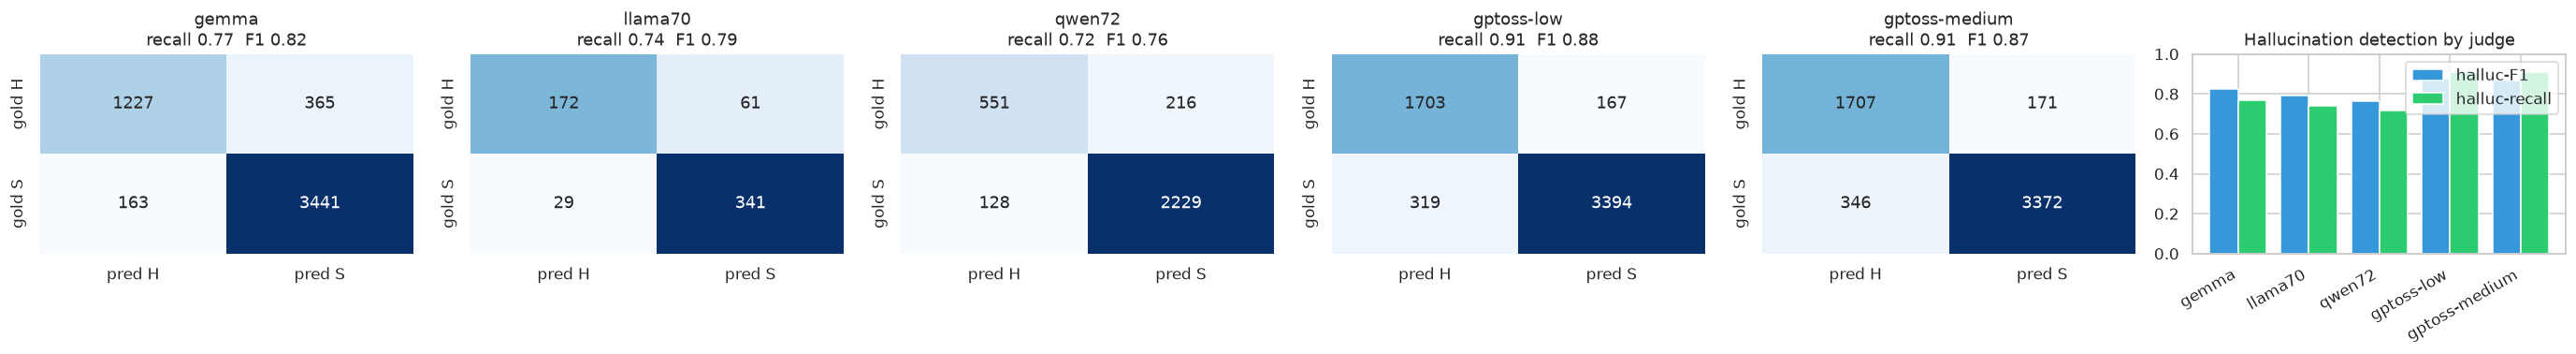

In [16]:
# Visual: per-judge confusion heatmaps + hallucination-F1 bars
present_m = {k: v for k, v in M.items() if v}
if present_m:
    n = len(present_m)
    fig, axes = plt.subplots(1, n + 1, figsize=(4.2 * (n + 1), 3.6))
    if n == 0:
        axes = [axes]
    for ax, (name, m) in zip(axes[:n], present_m.items()):
        sns.heatmap(m["cm"], annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                    xticklabels=["pred H", "pred S"], yticklabels=["gold H", "gold S"])
        ax.set_title(f"{name}\nrecall {m['recall']:.2f}  F1 {m['f1']:.2f}")
    axb = axes[n]
    names = list(present_m); f1s = [present_m[k]["f1"] for k in names]
    recs = [present_m[k]["recall"] for k in names]
    x = np.arange(len(names))
    axb.bar(x - 0.2, f1s, 0.4, label="halluc-F1", color=PALETTE["primary"])
    axb.bar(x + 0.2, recs, 0.4, label="halluc-recall", color=PALETTE["tertiary"])
    axb.set_xticks(x); axb.set_xticklabels(names, rotation=30, ha="right")
    axb.set_ylim(0, 1); axb.set_title("Hallucination detection by judge"); axb.legend()
    plt.tight_layout(); plt.show()
else:
    rprint("[dark_goldenrod]⚠[/dark_goldenrod] no judge verdicts yet - run the bake-off first")

## Combo selection

Scores every judge **pair**: on claims where both agree, how well the agreed verdict tracks gold
(kappa, hallucination-F1) and how much of the corpus is kept. The old design *discarded*
disagreements; here we report kept-rate so a combo that keeps more of the hard cases wins. The
best pair by hallucination-F1 at high kept-rate becomes the labeling combo.

In [17]:
from itertools import combinations
names = list(present_m)
rows = []
for a, b in combinations(names, 2):
    d = gdf.dropna(subset=[a, b])
    d = d[d[a].isin(_BIN) & d[b].isin(_BIN)]
    agree = d[d[a] == d[b]]
    if not len(agree):
        continue
    y = agree["gold"].to_numpy(); p = agree[a].map(_BIN).to_numpy()
    rows.append({"pair": f"{a}+{b}", "kept": len(agree), "kept_frac": len(agree) / max(len(d), 1),
                 "kappa": cohen_kappa_score(y, p) if len(set(y)) > 1 else float("nan"),
                 "halluc_F1": f1_score(y, p, pos_label=0, zero_division=0),
                 "recall": recall_score(y, p, pos_label=0, zero_division=0)})
combo = pd.DataFrame(rows)
if len(combo):
    combo = combo.sort_values("halluc_F1", ascending=False)
    t = Table(title="Judge combos - agreed verdict vs gold")
    for c in ("pair", "kept", "kept_frac", "kappa", "halluc-F1", "recall"):
        t.add_column(c)
    for _, r in combo.iterrows():
        t.add_row(r["pair"], str(int(r["kept"])), f"{r['kept_frac']:.2f}",
                  f"{r['kappa']:.3f}", f"{r['halluc_F1']:.3f}", f"{r['recall']:.3f}")
    rprint(t)
    BEST = combo.iloc[0]["pair"]
    rprint(f"[bold dark_sea_green]Best combo:[/bold dark_sea_green] [cadet_blue]{BEST}[/cadet_blue]")
else:
    BEST = None
    rprint("[dark_goldenrod]⚠[/dark_goldenrod] need >=2 judged candidates for a combo")

                   Judge combos - agreed verdict vs gold                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ pair                     ┃ kept ┃ kept_frac ┃ kappa ┃ halluc-F1 ┃ recall ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ llama70+gptoss-medium    │ 488  │ 0.83      │ 0.922 │ 0.948     │ 0.945  │
│ llama70+gptoss-low       │ 497  │ 0.85      │ 0.918 │ 0.945     │ 0.929  │
│ gemma+gptoss-medium      │ 4432 │ 0.88      │ 0.909 │ 0.934     │ 0.931  │
│ gemma+gptoss-low         │ 4466 │ 0.89      │ 0.903 │ 0.930     │ 0.923  │
│ qwen72+gptoss-medium     │ 2664 │ 0.88      │ 0.881 │ 0.906     │ 0.903  │
│ qwen72+gptoss-low        │ 2667 │ 0.88      │ 0.881 │ 0.906     │ 0.900  │
│ gptoss-low+gptoss-medium │ 5268 │ 0.96      │ 0.848 │ 0.900     │ 0.932  │
│ llama70+qwen72           │ 338  │ 0.93      │ 0.841 │ 0.880     │ 0.811  │
│ gemma+qwen72             │ 2597 │ 0.91      │ 0.816 │ 0.847     │ 0.802  │
│ gemma+llama70            │ 497  │ 0.88      │ 0.756 │ 0.824     │ 0.713  │
└──────────────────────────┴──────┴───────────┴───────┴───────────┴────────┘

Best combo: llama70+gptoss-medium

## Per-language kappa

Breaks the winning combo's agreement-with-gold down by language. The cross-lingual slices
(Norwegian `nb`, French, Spanish) are the stress test - claims in one language, English evidence.

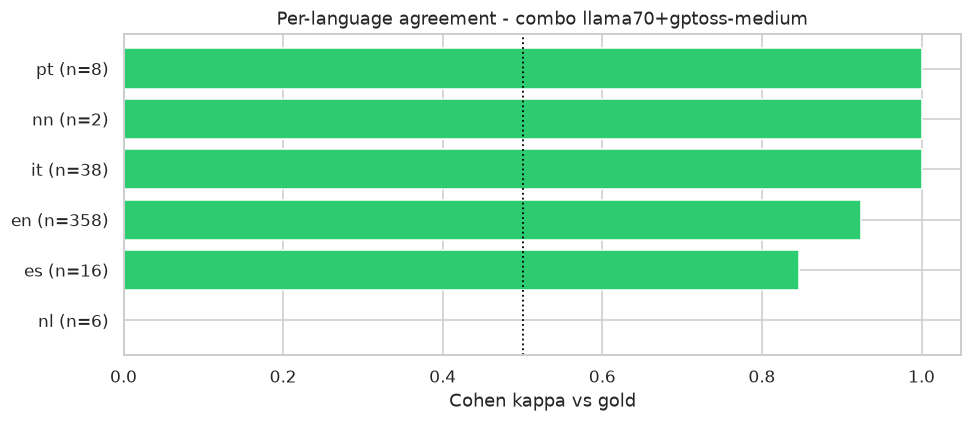

In [18]:
if BEST:
    a, b = BEST.split("+")
    d = gdf.dropna(subset=[a, b]); d = d[d[a].isin(_BIN) & d[b].isin(_BIN)]
    d = d[d[a] == d[b]].copy(); d["p"] = d[a].map(_BIN)
    rows = []
    for lg, gl in d.groupby("lang"):
        if len(set(gl["gold"])) > 1:
            rows.append({"lang": lg, "n": len(gl),
                         "kappa": cohen_kappa_score(gl["gold"], gl["p"]),
                         "acc": (gl["gold"].to_numpy() == gl["p"].to_numpy()).mean()})
    ldf = pd.DataFrame(rows).sort_values("kappa")
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = [PALETTE["secondary"] if k < 0.5 else PALETTE["tertiary"] for k in ldf["kappa"]]
    ax.barh(ldf["lang"] + " (n=" + ldf["n"].astype(str) + ")", ldf["kappa"], color=colors)
    ax.axvline(0.5, color="black", ls=":", lw=1.2)
    ax.set_xlabel("Cohen kappa vs gold"); ax.set_title(f"Per-language agreement - combo {BEST}")
    plt.tight_layout(); plt.show()
else:
    rprint("[dark_goldenrod]⚠[/dark_goldenrod] no combo selected yet")

## Save - final labeled dataset

Writes the winning combo's dual-agreed, non-`NOT_A_CLAIM` verdicts as the final hallucination-
labeled dataset. For validated (gold) traces this is the re-labeled set; with `LLM_JUDGE_PHASE2=1`
it extends to the unlabeled traces via `extract_claims`. Schema mirrors the project's
`records_open.parquet`.

In [19]:
if BEST:
    a, b = BEST.split("+")
    d = gdf.dropna(subset=[a, b]); d = d[d[a] == d[b]]
    d = d[d[a].isin(_BIN)].copy()
    d["label"] = d[a].map(_BIN)
    # attach claim text + evidence pointer
    claim_lookup = {(u["trace_id"], pos): u["claims"][pos] for u in units for pos in range(len(u["claims"]))}
    d["claim"] = [claim_lookup.get((t, p), "") for t, p in zip(d["trace_id"], d["pos"])]
    records = d[["claim", "label", "lang", "trace_id"]].copy()
    records["origin"] = "open_judged"
    REC_PATH = OUT / "records_open.parquet"
    records.to_parquet(REC_PATH)
    rprint(f"[dark_sea_green]✓[/dark_sea_green] wrote [dark_sea_green]{len(records)}[/dark_sea_green] "
           f"dual-agreed records -> [cadet_blue]{REC_PATH.name}[/cadet_blue]")
else:
    records = None
    rprint("[dark_goldenrod]⚠[/dark_goldenrod] no combo - dataset not written")

✓ wrote 488 dual-agreed records -> records_open.parquet

## Summary

Final label distribution of the produced dataset and the aggregate report. All outputs are
aggregate metrics only - no client text is written to any tracked artifact.

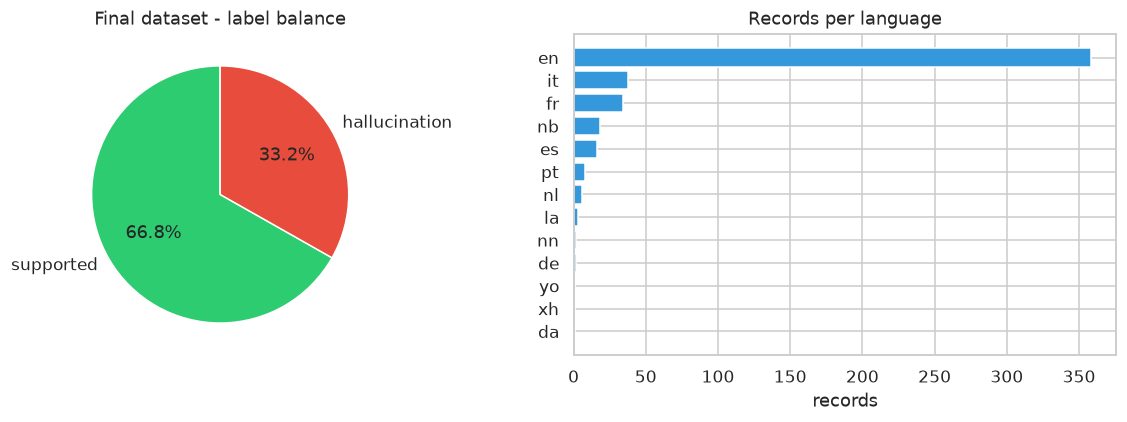

✓ pipeline complete - report -> ../../data/processed/dataset_pipeline/REPORT.md

In [20]:
if records is not None and len(records):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
    vc = records["label"].map({1: "supported", 0: "hallucination"}).value_counts()
    a1.pie(vc.values, labels=vc.index, autopct="%1.1f%%",
           colors=[PALETTE["tertiary"], PALETTE["secondary"]], startangle=90)
    a1.set_title("Final dataset - label balance")
    lc = records.groupby("lang").size().sort_values()
    a2.barh(lc.index, lc.values, color=PALETTE["primary"])
    a2.set_xlabel("records"); a2.set_title("Records per language")
    plt.tight_layout(); plt.show()

    lines = [f"# Grounding dataset pipeline - report\n",
             f"Best combo: {BEST}",
             f"Records: {len(records)}  (supported {int((records['label']==1).sum())}, "
             f"hallucination {int((records['label']==0).sum())})",
             f"Retrieval recall (gold-supported): {recall:.3f}"]
    (OUT / "REPORT.md").write_text("\n".join(lines))
    rprint(f"[dark_sea_green]✓ pipeline complete[/dark_sea_green] - report -> {OUT/'REPORT.md'}")
else:
    rprint("[steel_blue]CPU stages complete.[/steel_blue] Download judges, then re-run per "
           "candidate: [grey70]JUDGE_CANDIDATE=gemma|llama70|qwen72|gptoss-low|gptoss-high[/grey70]")